### Ortam Hazırlığı 

- Gerekli kütüphaneleri yüklüyoruz
- Sonuçların tekrar edilebilir olması için seed ayarlıyoruz


In [28]:
import os
import random
from dataclasses import dataclass

import numpy as np
import torch

print("Python:", os.sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

# Cihaz seçimi
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Seed set to:", SEED)


Python: 3.13.5
PyTorch: 2.7.1+cu118
CUDA available: True
DEVICE: cuda
Seed set to: 42


### Dataset Yolunu Tanımlama ve Klasör Yapısını Kontrol

- Dataset'in kök klasör yolunu giriyoruz
- train/val/test klasörleri var mı kontrol ediyoruz
- Her birinde 4 sınıf klasörü ve görüntü sayıları yazdırılıyor


In [29]:
from pathlib import Path

# Dataset yolu
DATASET_ROOT = Path(r"C:\Users\emirk\OneDrive\Desktop\Dersler-Yazılımlar\YTÜ\Derin Öğrenme ve Yapay Sinir Ağları\Dataset\RIAWELC_dataset\DB - Copy")

assert DATASET_ROOT.exists(), f"Dataset root bulunamadi: {DATASET_ROOT}"

splits = {
    "train": "training",
    "val": "validation",
    "test": "testing"
}

def count_images(folder: Path):
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
    return sum(1 for p in folder.rglob("*") if p.suffix.lower() in exts)

print("Dataset root:", DATASET_ROOT)

for split_name, split_folder in splits.items():
    split_dir = DATASET_ROOT / split_folder
    assert split_dir.exists(), f"Eksik klasor: {split_dir}"

    class_dirs = sorted([d for d in split_dir.iterdir() if d.is_dir()])
    class_names = [d.name for d in class_dirs]

    print(f"\n[{split_name.upper()}] siniflar:", class_names)

    for cname in class_names:
        n = count_images(split_dir / cname)
        print(f"  - {split_name}/{cname}: {n}")

total = sum(count_images(DATASET_ROOT / s) for s in splits.values())
print("\nToplam goruntu sayisi:", total)


Dataset root: C:\Users\emirk\OneDrive\Desktop\Dersler-Yazılımlar\YTÜ\Derin Öğrenme ve Yapay Sinir Ağları\Dataset\RIAWELC_dataset\DB - Copy

[TRAIN] siniflar: ['Difetto1', 'Difetto2', 'Difetto4', 'NoDifetto']
  - train/Difetto1: 4962
  - train/Difetto2: 4108
  - train/Difetto4: 2893
  - train/NoDifetto: 3900

[VAL] siniflar: ['Difetto1', 'Difetto2', 'Difetto4', 'NoDifetto']
  - val/Difetto1: 1908
  - val/Difetto2: 1580
  - val/Difetto4: 1113
  - val/NoDifetto: 1500

[TEST] siniflar: ['Difetto1', 'Difetto2', 'Difetto4', 'NoDifetto']
  - test/Difetto1: 765
  - test/Difetto2: 632
  - test/Difetto4: 446
  - test/NoDifetto: 600

Toplam goruntu sayisi: 24407


### Dataset ve Transform'lar 

- Sadece TRAIN için düşük şiddet data augmentation tanımlıyoruz
- Val/Test için sadece normalize + resize yapıyoruz
- ImageFolder ile datasetleri kuruyoruz
- DataLoader ile ilk batch'i kontrol ediyoruz


In [30]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Split klasör adları
SPLITS = {"train": "training", "val": "validation", "test": "testing"}

# ImageNet normalize 
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# Düşük şiddet augmentation (Sadece Train) 
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),                 
    transforms.RandomRotation(degrees=5),          
    transforms.ColorJitter(brightness=0.05, contrast=0.05), 
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Val/Test: Augmentation yok
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Datasetler
train_ds = datasets.ImageFolder(root=DATASET_ROOT / SPLITS["train"], transform=train_transform)
val_ds   = datasets.ImageFolder(root=DATASET_ROOT / SPLITS["val"],   transform=eval_transform)
test_ds  = datasets.ImageFolder(root=DATASET_ROOT / SPLITS["test"],  transform=eval_transform)

print("Class to idx:", train_ds.class_to_idx)

# DataLoader (Bildirideki batch size = 32)
BATCH_SIZE = 32
NUM_WORKERS = 2

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# Batch kontrolü
xb, yb = next(iter(train_loader))
print("Train batch X shape:", xb.shape)  
print("Train batch y shape:", yb.shape)  
print("y min/max:", int(yb.min()), int(yb.max()))
print("Device ready:", DEVICE)


Class to idx: {'Difetto1': 0, 'Difetto2': 1, 'Difetto4': 2, 'NoDifetto': 3}
Train batch X shape: torch.Size([32, 3, 224, 224])
Train batch y shape: torch.Size([32])
y min/max: 0 3
Device ready: cuda


### Model Kurulumu (SqueezeNet + Özgün Head) ve Backbone Freeze

- ImageNet-pretrained SqueezeNet backbone yüklenir
- Backbone overfitting riskini azaltmak için tamamen freeze edilir.
- Paper'daki "New Conv + Global Pooling + Softmax" fikri korunur,
  ancak temsil gücünü artırmak için head şu şekilde güçlendirilir:
  Conv1x1(256) + BN + ReLU + GAP + Dropout(0.4) + FC(4)
- Sadece head parametrelerinin trainable olduğu kontrol edilir


In [31]:
import torch
import torch.nn as nn
from torchvision import models

NUM_CLASSES = 4
DROPOUT_P = 0.4

# Pretrained SqueezeNet yükle
model = models.squeezenet1_1(weights=models.SqueezeNet1_1_Weights.IMAGENET1K_V1)

# Backbone tamamen freeze
for p in model.features.parameters():
    p.requires_grad = False

# Özgün head tanımı
# SqueezeNet'in classifier kısmını değiştiriyoruz.

model.classifier = nn.Sequential(
    nn.Conv2d(in_channels=512, out_channels=256, kernel_size=1),  # Fire9 çıkışı 512
    nn.BatchNorm2d(256),
    nn.ReLU(inplace=True),
    nn.AdaptiveAvgPool2d((1, 1)),  # GAP
    nn.Dropout(p=DROPOUT_P),
    nn.Flatten(),
    nn.Linear(256, NUM_CLASSES)
)

model = model.to(DEVICE)

# Trainable parametre kontrolü
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total params:", total_params)
print("Trainable params:", trainable_params)

# Bir forward-pass test
model.eval()
with torch.no_grad():
    xb, yb = next(iter(train_loader))
    xb = xb.to(DEVICE)
    out = model(xb)
print("Logits shape:", out.shape)  # (B, 4) beklenir


Total params: 855364
Trainable params: 132868
Logits shape: torch.Size([32, 4])


### Eğitim Ayarları (Loss, AdamW, Weight Decay, Early Stopping)

- Loss fonksiyonunu (CrossEntropy) tanımlıyoruz
- Sadece trainable parametreleri AdamW ile optimize ediyoruz
- Weight decay ile overfitting'i azaltıyoruz
- Early stopping için izlenecek metrik ve patience ayarlarını kuruyoruz


In [32]:
import torch
import torch.nn as nn

# Hiperparametreler
LR = 1e-4
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 100
PATIENCE = 7

# Loss
criterion = nn.CrossEntropyLoss()

# Sadece trainable parametreler optimize edilsin
trainable_params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.AdamW(trainable_params, lr=LR, weight_decay=WEIGHT_DECAY)

print("LR:", LR)
print("Weight decay:", WEIGHT_DECAY)
print("Max epochs:", MAX_EPOCHS)
print("Early stopping patience:", PATIENCE)
print("Trainable param tensors:", len(trainable_params))

# Early stopping değişkenleri
best_val_loss = float("inf")
best_epoch = -1
patience_counter = 0

# En iyi modeli saklamak için (RAM'de state_dict kopyası)
best_state_dict = None


LR: 0.0001
Weight decay: 0.0001
Max epochs: 100
Early stopping patience: 7
Trainable param tensors: 6


### Eğitim ve Doğrulama Döngüsü

- Model epoch bazlı eğitilir
- Her epoch sonunda validation yapılır
- Validation loss iyileşmezse early stopping uygulanır
- En iyi model val loss'a göre saklanır


In [33]:
from tqdm import tqdm

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for xb, yb in tqdm(loader, leave=False):
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            outputs = model(xb)
            loss = criterion(outputs, yb)

            running_loss += loss.item() * xb.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


# Eğitim döngüsü
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

print("Training started...\n")

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE
    )
    val_loss, val_acc = evaluate(
        model, val_loader, criterion, DEVICE
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch [{epoch:02d}/{MAX_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )

    # Early stopping kontrolü 
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        patience_counter = 0
        best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1
        print(f"  ↳ Early stopping counter: {patience_counter}/{PATIENCE}")

    if patience_counter >= PATIENCE:
        print("\nEarly stopping triggered!")
        break

print(f"\nBest epoch: {best_epoch}, Best val loss: {best_val_loss:.4f}")


Training started...



Epoch [01/100] | Train Loss: 0.9247, Train Acc: 0.6580 | Val Loss: 0.6452, Val Acc: 0.7786


Epoch [02/100] | Train Loss: 0.6407, Train Acc: 0.7775 | Val Loss: 0.4926, Val Acc: 0.8361


Epoch [03/100] | Train Loss: 0.5401, Train Acc: 0.8138 | Val Loss: 0.4261, Val Acc: 0.8564


Epoch [04/100] | Train Loss: 0.4902, Train Acc: 0.8302 | Val Loss: 0.3700, Val Acc: 0.8764


...

Epoch [66/100] | Train Loss: 0.2748, Train Acc: 0.9009 | Val Loss: 0.1926, Val Acc: 0.9305
  ↳ Early stopping counter: 3/7


Epoch [67/100] | Train Loss: 0.2674, Train Acc: 0.9017 | Val Loss: 0.1867, Val Acc: 0.9341
  ↳ Early stopping counter: 4/7


Epoch [68/100] | Train Loss: 0.2684, Train Acc: 0.8998 | Val Loss: 0.2000, Val Acc: 0.9276
  ↳ Early stopping counter: 5/7


Epoch [69/100] | Train Loss: 0.2700, Train Acc: 0.9025 | Val Loss: 0.2041, Val Acc: 0.9272
  ↳ Early stopping counter: 6/7


Epoch [70/100] | Train Loss: 0.2668, Train Acc: 0.9035 | Val Loss: 0.1882, Val Acc: 0.9328
  ↳ Early stopping counter: 7/7

Early stopping triggered!

Best epoch: 63, Best val loss: 0.1816


### Sınıf İsimleri (CR/PO/LP/ND)

Bu hücrede:
- Dataset klasör isimlerini (Difetto1, Difetto2, Difetto4, NoDifetto)
  paper'daki kısaltmalarla eşliyoruz:
  - Difetto1 = CR (Cracks)
  - Difetto2 = PO (Porosity)
  - Difetto4 = LP (Lack of Penetration)
  - NoDifetto = ND (No Defect)


In [64]:
# Orijinal sinif isimleri
class_names = train_ds.classes
print("Original class names:", class_names)

# Paper uyumlu isimlendirme (mapping)
class_name_map = {
    "Difetto1": "CR",  # Cracks
    "Difetto2": "PO",  # Porosity
    "Difetto4": "LP",  # Lack of Penetration
    "NoDifetto": "ND"  # No Defect
}

class_names_paper = [class_name_map[c] for c in class_names]
print("Paper-style class names:", class_names_paper)


Original class names: ['Difetto1', 'Difetto2', 'Difetto4', 'NoDifetto']
Paper-style class names: ['CR', 'PO', 'LP', 'ND']


### Test Seti Değerlendirmesi

Bu hücrede:
- Validation loss'a göre seçilen en iyi model yüklenir
- Test seti üzerinde:
  - Accuracy
  - Macro F1-score
  - Confusion Matrix
hesaplanır


In [65]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import numpy as np

# En iyi modeli geri yükler
model.load_state_dict(best_state_dict)
model.to(DEVICE)
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        outputs = model(xb)
        _, preds = torch.max(outputs, 1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(yb.cpu().numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

# Metrikler
test_acc = accuracy_score(all_labels, all_preds)
test_f1 = f1_score(all_labels, all_preds, average="macro")
cm = confusion_matrix(all_labels, all_preds)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Macro F1: {test_f1:.4f}")
print("\nConfusion Matrix:")
print(cm)

# Sınıf isimleri
class_names = train_ds.classes
print("\nClass names:", class_names_paper)


Test Accuracy: 0.9353
Test Macro F1: 0.9319

Confusion Matrix:
[[701  14  42   8]
 [ 17 582  27   6]
 [ 19   7 406  14]
 [  0   0   4 596]]

Class names: ['CR', 'PO', 'LP', 'ND']


### Eğitim Eğrileri (Loss ve Accuracy)

Bu hücrede:
- Train/Val loss eğrilerini çiziyoruz
- Train/Val accuracy eğrilerini çiziyoruz
Amaç:
- Modelin öğrenme sürecini görmek
- Overfitting/underfitting olmadığını görsel olarak göstermek


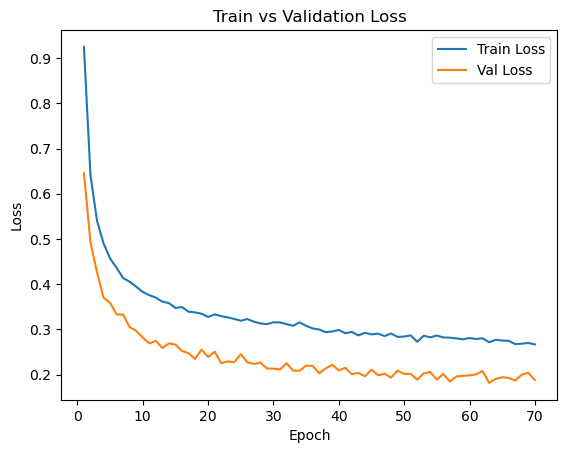

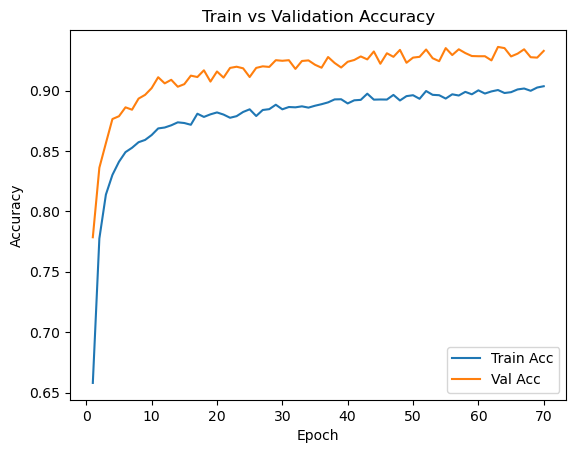

In [66]:
import matplotlib.pyplot as plt

epochs_ran = len(history["train_loss"])
epochs = list(range(1, epochs_ran + 1))

# Loss grafiği
plt.figure()
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.show()

# Accuracy grafiği
plt.figure()
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy")
plt.legend()
plt.show()


### Confusion Matrix Görselleştirme

Bu hücrede:
- Test setinde elde edilen confusion matrix'i görsel hale getiriyoruz
- Hücre içindeki sayılar: kaç örnek hangi sınıfa gitmiş
- Böylece hangi kusurların karıştığı netleşir


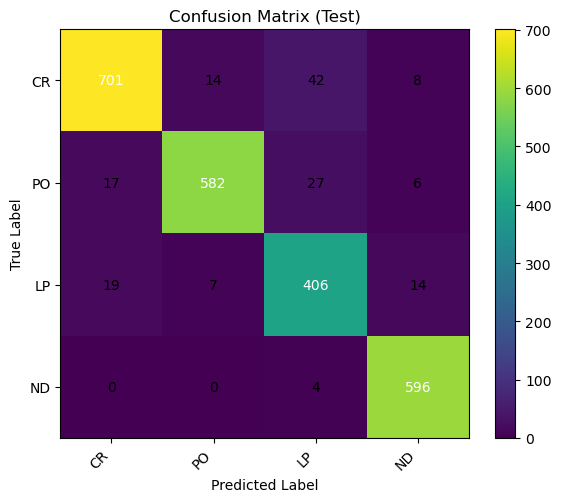

In [67]:
import matplotlib.pyplot as plt
import numpy as np

cm_arr = cm  

plt.figure(figsize=(6, 5))
plt.imshow(cm_arr, interpolation="nearest")
plt.title("Confusion Matrix (Test)")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names_paper, rotation=45, ha="right")
plt.yticks(tick_marks, class_names_paper)

thresh = cm_arr.max() / 2.0
for i in range(cm_arr.shape[0]):
    for j in range(cm_arr.shape[1]):
        plt.text(
            j, i, format(cm_arr[i, j], "d"),
            ha="center", va="center",
            color="white" if cm_arr[i, j] > thresh else "black"
        )

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()


### Sınıf Bazlı Performans Tablosu (Precision / Recall / F1)

- Test seti üzerinde her sınıf icin Precision, Recall, F1-score ve Support hesaplıyoruz
- Ayrıca Macro ve Weighted ortalamaları da raporlamak icin tabloya ekliyoruz
- Macro F1, siniflarin dengeli degerlendirilmesini saglar


In [68]:
from sklearn.metrics import classification_report
import pandas as pd

report_dict = classification_report(
    all_labels, all_preds,
    target_names=class_names_paper,
    output_dict=True,
    digits=4
)

df_report = pd.DataFrame(report_dict).T  

cols_order = [c for c in ["precision", "recall", "f1-score", "support"] if c in df_report.columns]
df_report = df_report[cols_order]

if "support" in df_report.columns:
    df_report["support"] = df_report["support"].astype(int)

print(df_report)


              precision    recall  f1-score  support
CR             0.951153  0.916340  0.933422      765
PO             0.965174  0.920886  0.942510      632
LP             0.847599  0.910314  0.877838      446
ND             0.955128  0.993333  0.973856      600
accuracy       0.935325  0.935325  0.935325        0
macro avg      0.929764  0.935218  0.931907     2443
weighted avg   0.936852  0.935325  0.935556     2443


### Normalize Confusion Matrix (Yuzde)

- Confusion matrix'i satır bazlı normalize ediyoruz
- Böylece her sınıfın hangi sınıflara ne oranda kaydığı daha net görülür


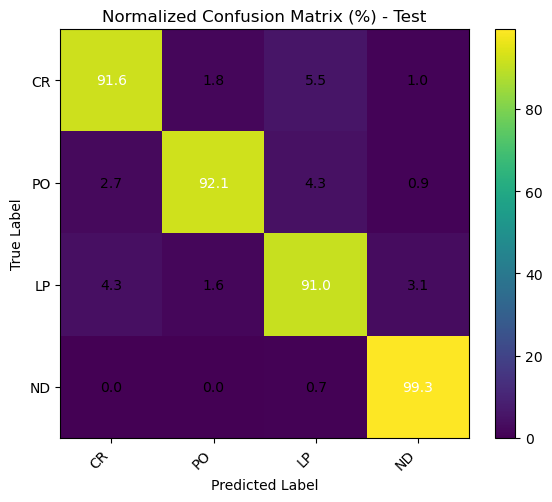

Normalized CM (%):
 [[91.63  1.83  5.49  1.05]
 [ 2.69 92.09  4.27  0.95]
 [ 4.26  1.57 91.03  3.14]
 [ 0.    0.    0.67 99.33]]


In [69]:
import numpy as np
import matplotlib.pyplot as plt

cm_arr = cm.astype(np.float64)

# Satır bazlı normalizasyon
row_sums = cm_arr.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm_arr, row_sums, out=np.zeros_like(cm_arr), where=row_sums != 0)

cm_pct = cm_norm * 100.0

plt.figure(figsize=(6, 5))
plt.imshow(cm_pct, interpolation="nearest")
plt.title("Normalized Confusion Matrix (%) - Test")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names_paper, rotation=45, ha="right")
plt.yticks(tick_marks, class_names_paper)

thresh = cm_pct.max() / 2.0
for i in range(cm_pct.shape[0]):
    for j in range(cm_pct.shape[1]):
        plt.text(
            j, i, f"{cm_pct[i, j]:.1f}",
            ha="center", va="center",
            color="white" if cm_pct[i, j] > thresh else "black"
        )

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

print("Normalized CM (%):\n", np.round(cm_pct, 2))


### En Çok Karışan Sınıflar Hata Analizi Tablosu

- Diyagonal dışındaki hataları inceliyoruz
- Hangi gercek sınıfın hangi sınıfa en cok karıstığını listeliyoruz


In [71]:
import pandas as pd
import numpy as np

cm_int = cm.copy()
n = cm_int.shape[0]

rows = []
for i in range(n):
    for j in range(n):
        if i == j:
            continue
        rows.append({
            "true_class": class_names[i],
            "pred_class": class_names[j],
            "count": int(cm_int[i, j]),
            "true_total": int(cm_int[i, :].sum()),
            "pct_of_true(%)": (cm_int[i, j] / cm_int[i, :].sum() * 100.0) if cm_int[i, :].sum() > 0 else 0.0
        })

df_mis = pd.DataFrame(rows)
df_mis = df_mis.sort_values(["count", "pct_of_true(%)"], ascending=[False, False]).reset_index(drop=True)

df_mis_paper = df_mis.copy()
df_mis_paper["true_class"] = df_mis_paper["true_class"].map(class_name_map)
df_mis_paper["pred_class"] = df_mis_paper["pred_class"].map(class_name_map)

print("Top-10 En Çok Karışma:")
print(df_mis_paper.head(10))



Top-10 En Çok Karışma:
  true_class pred_class  count  true_total  pct_of_true(%)
0         CR         LP     42         765        5.490196
1         PO         LP     27         632        4.272152
2         LP         CR     19         446        4.260090
3         PO         CR     17         632        2.689873
4         LP         ND     14         446        3.139013
5         CR         PO     14         765        1.830065
6         CR         ND      8         765        1.045752
7         LP         PO      7         446        1.569507
8         PO         ND      6         632        0.949367
9         ND         LP      4         600        0.666667


### Çıktı Klasörü Oluşturma

- Grafik ve tabloların kaydedileceği bir klasor oluşturuyoruz
- Tum rapor çıktıları bu klasore kaydedilecek


In [72]:
from pathlib import Path

OUTPUT_DIR = Path("report_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Cikti klasoru:", OUTPUT_DIR.resolve())


Cikti klasoru: C:\Users\emirk\OneDrive\Desktop\Proje\report_outputs


### Eğitim Eğrilerini Dosyaya Kaydetme

- Train/Val Loss grafiğini PNG olarak kaydediyoruz
- Train/Val Accuracy grafiğini PNG olarak kaydediyoruz


In [73]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(history["train_loss"]) + 1))

# Loss
plt.figure()
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "train_val_loss.png", dpi=300)
plt.close()

# Accuracy
plt.figure()
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "train_val_accuracy.png", dpi=300)
plt.close()

print("Egitim egrileri kaydedildi.")


Egitim egrileri kaydedildi.


### Confusion Matrix (Ham) PNG Olarak Kaydetme


In [74]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix (Test)")
plt.colorbar()

ticks = np.arange(len(class_names))
plt.xticks(ticks, class_names_paper, rotation=45, ha="right")
plt.yticks(ticks, class_names_paper)

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, format(cm[i, j], "d"),
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black"
        )

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_raw.png", dpi=300)
plt.close()

print("Ham confusion matrix kaydedildi.")


Ham confusion matrix kaydedildi.


### Normalize Confusion Matrix (Yuzde) PNG Olarak Kaydetme


In [75]:
cm_arr = cm.astype(float)
cm_norm = cm_arr / cm_arr.sum(axis=1, keepdims=True)
cm_pct = cm_norm * 100.0

plt.figure(figsize=(6, 5))
plt.imshow(cm_pct, interpolation="nearest")
plt.title("Normalized Confusion Matrix (%) - Test")
plt.colorbar()

plt.xticks(ticks, class_names_paper, rotation=45, ha="right")
plt.yticks(ticks, class_names_paper)

thresh = cm_pct.max() / 2.0
for i in range(cm_pct.shape[0]):
    for j in range(cm_pct.shape[1]):
        plt.text(
            j, i, f"{cm_pct[i, j]:.1f}",
            ha="center", va="center",
            color="white" if cm_pct[i, j] > thresh else "black"
        )

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_normalized.png", dpi=300)
plt.close()

print("Normalize confusion matrix kaydedildi.")


Normalize confusion matrix kaydedildi.


### Sınıf Bazlı Performans Tablosunu PNG Olarak Kaydetme

- Precision / Recall / F1 / Support tablosunu


In [76]:
import matplotlib.pyplot as plt

def save_table_as_png(df, filename, title):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.axis("off")

    table = ax.table(
        cellText=df.round(4).values,
        colLabels=df.columns,
        rowLabels=df.index,
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)

    plt.title(title, pad=20)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=300)
    plt.close()

# Classification report PNG
save_table_as_png(
    df_report,
    "classification_report.png",
    "Class-wise Precision / Recall / F1-score (Test)"
)

print("Classification report PNG olarak kaydedildi.")


Classification report PNG olarak kaydedildi.


### En Çok Karışan Sınıflar Tablosunu PNG Olarak Kaydetme


In [77]:
df_mis_top10 = df_mis_paper.head(10)

save_table_as_png(
    df_mis_top10,
    "most_confused_classes.png",
    "Top-10 Most Confused Class Pairs (Test)"
)

print("Most confused classes PNG olarak kaydedildi.")



Most confused classes PNG olarak kaydedildi.


### IEEE / Overleaf Icin LaTeX Tablo Çıktıları


In [78]:
# Classification report (LaTeX)
df_report.to_latex(
    OUTPUT_DIR / "classification_report.tex",
    float_format="%.4f",
    caption="Class-wise precision, recall and F1-score on the test set.",
    label="tab:classification_report"
)

# Most confused classes (LaTeX)
df_mis_top10.to_latex(
    OUTPUT_DIR / "most_confused_classes.tex",
    float_format="%.2f",
    index=False,
    caption="Top-10 most confused class pairs on the test set.",
    label="tab:most_confused"
)

print("LaTeX tablolar kaydedildi.")


LaTeX tablolar kaydedildi.


### Accuracy Results Tablosu

- En iyi epoch'taki train/val accuracy ve loss değerlerini alıyoruz
- Test accuracy zaten hesaplandı 
- Test loss'u da en iyi modelle hesaplıyoruz 


In [79]:
import numpy as np
import torch

best_idx = best_epoch - 1

best_train_acc = history["train_acc"][best_idx]
best_val_acc   = history["val_acc"][best_idx]
best_train_loss = history["train_loss"][best_idx]
best_val_loss   = history["val_loss"][best_idx]

print("Best epoch:", best_epoch)
print("Best Train Acc:", best_train_acc, "Best Val Acc:", best_val_acc)
print("Best Train Loss:", best_train_loss, "Best Val Loss:", best_val_loss)

model.load_state_dict(best_state_dict)
model.to(DEVICE)
model.eval()

test_running_loss = 0.0
test_total = 0

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        outputs = model(xb)
        loss = criterion(outputs, yb)

        test_running_loss += loss.item() * xb.size(0)
        test_total += yb.size(0)

test_loss = test_running_loss / test_total
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)
print("Test Macro F1:", test_f1)


Best epoch: 63
Best Train Acc: 0.9003971506020298 Best Val Acc: 0.9360760531060481
Best Train Loss: 0.27156588195446857 Best Val Loss: 0.1816183723778893
Test Loss: 0.18466657567868405
Test Accuracy: 0.9353254195661073
Test Macro F1: 0.9319065680767932


###  TABLE - Accuracy Results
- IEEE/Overleaf için LaTeX (.tex)
- Sunum icin PNG (.png)


In [80]:
import pandas as pd

# Yuzde formatina cevir (accuracy %)
def pct(x): 
    return f"{x*100:.2f}%"

table_df = pd.DataFrame({
    "Metric": [
        "Train accuracy",
        "Validation accuracy",
        "Train loss",
        "Validation loss",
        "Test accuracy",
        "Test loss"
    ],
    "Value": [
        pct(best_train_acc),
        pct(best_val_acc),
        f"{best_train_loss:.4f}",
        f"{best_val_loss:.4f}",
        pct(test_acc),
        f"{test_loss:.4f}"
    ]
})

print(table_df)

# 1) LaTeX kaydet (Overleaf)
latex_path = OUTPUT_DIR / "accuracy_results_table.tex"
table_df.to_latex(
    latex_path,
    index=False,
    caption="Accuracy results of the proposed model.",
    label="tab:accuracy_results"
)
print("LaTeX tablo kaydedildi:", latex_path)

# 2) PNG kaydet (sunum)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.5, 2.8))
ax.axis("off")

tbl = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    cellLoc="center",
    loc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.4)

plt.title("ACCURACY RESULTS", pad=10)
plt.tight_layout()
png_path = OUTPUT_DIR / "accuracy_results_table.png"
plt.savefig(png_path, dpi=300)
plt.close()

print("PNG tablo kaydedildi:", png_path)


                Metric   Value
0       Train accuracy  90.04%
1  Validation accuracy  93.61%
2           Train loss  0.2716
3      Validation loss  0.1816
4        Test accuracy  93.53%
5            Test loss  0.1847
LaTeX tablo kaydedildi: report_outputs\accuracy_results_table.tex
PNG tablo kaydedildi: report_outputs\accuracy_results_table.png
